# Import Statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet

In [3]:

from sklearn.preprocessing import OneHotEncoder
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns


/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.linear_model import Lasso

from sklearn.metrics import accuracy_score


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [6]:
import tqdm as notebook_tqdm
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [7]:
from platform import python_version

print(python_version())


3.10.12


In [8]:
print(np.__version__)

1.26.3


# Define all functions

In [7]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}

# set parameter space for LASSO

elasticnet_space = {
    'alpha': Real(1e-3, 1.0, 'log-uniform'),
    'l1_ratio': Real(0.1, 0.99, 'uniform')
}

In [8]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [9]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

def bayesian_elasticnet_search(X, y, elasticnet_space):
    elasticnet = ElasticNet(max_iter=100000)
    elasticnet_bayes_search = BayesSearchCV(
        estimator=elasticnet,
        search_spaces=elasticnet_space,
        scoring=None,
        cv=5,
        n_iter=10,  # number of iterations to try
        random_state=42,
        verbose=2,
        n_jobs=-1
)
    elasticnet_bayes_search.fit(X, y)
    
    print("Best ElasticNet hyperparameters:", elasticnet_bayes_search.best_params_)
    
    best_params = elasticnet_bayes_search.best_params_
    best_elasticnet = ElasticNet(**best_params)

    return best_elasticnet
    
#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [10]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [11]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [12]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = [x for x in best_model.predict(X_holdout)]

    # Compute performance metrics
    ss = sqrt(mean_squared_error(all_preds, y_holdout))
    rr = r2_score(all_preds, y_holdout)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100

    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")

    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    plot_x, plot_y = [], []

    for counter, actual in enumerate(y_holdout):
        if counter <= 5:  # Print first 5 examples
            print(counter, actual, all_preds[counter])
        if all_preds[counter] > 1:
            plot_x.append(actual)
            plot_y.append(all_preds[counter])

    # Create a DataFrame for plotting
    thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()


    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [13]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Load dataset

In [14]:
#Load file
tt_prt = pd.read_pickle("pickle_files/training_data_prt.pkl")
tt_prt.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [15]:
tt_prt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100_BeiJing_2013 to s99_BeiJing_2013
Columns: 251240 entries, Line to PRT
dtypes: float64(4), int64(251235), object(1)
memory usage: 2.0+ GB


In [16]:
#Extract only SNPs for feature selection

In [17]:
feature= tt_prt.iloc[:, 1:251229]
feature.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s101_HeiLongJiang_2014,0,0,1,0,0,1,1,0,0,0,...,2,0,1,0,0,2,2,0,2,0


In [18]:
feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100_BeiJing_2013 to s99_BeiJing_2013
Columns: 251228 entries, Chr1_15246 to Chr20_52267897
dtypes: int64(251228)
memory usage: 2.0+ GB


In [19]:
target = tt_prt["PRT"]
target.head()

new_line
s100_BeiJing_2013         340.553
s100_HeNan_2014           358.104
s1014_BeiJing_2013        366.116
s1014_HeNan_2014          326.667
s101_HeiLongJiang_2014    385.915
Name: PRT, dtype: float64

In [22]:
cov = tt_prt.iloc[:,-10:]
cov.head()

,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,
s100_BeiJing_2013,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [21]:
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [59]:
#X_train_subset = X_train.iloc[:, :1000]
#X_train_subset.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr1_4969562,Chr1_4982468,Chr1_4988225,Chr1_4990892,Chr1_5004708,Chr1_5007930,Chr1_5012238,Chr1_5022900,Chr1_5022975,Chr1_5023098
new_line,,,,,,,,,,,,,,,,,,,,,
s461_BeiJing_2013,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
s560_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
s130_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s2427_HeiLongJiang_2014,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,2,0,1,0
s789_BeiJing_2013,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
best_elasticnet = bayesian_elasticnet_search(X_train, y_train, elasticnet_space)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time= 7.5min
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time= 9.8min
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time=12.1min
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time=12.3min
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  19.8s
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  20.3s
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  22.2s
[CV] END alpha=0.016994636371262764, l1_ratio=0.7476759114278193; total time=32.5min
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; total time=  34.2s
[CV] END alpha=0.3252108800594495, l1_ratio=0.8861505968689674; to

In [23]:
# Create a ElasticNet Regression model with the best parameters from bayes CV
#Best Parameters: OrderedDict([('alpha', 0.7352481813242628), ('l1_ratio', 0.7235530857130157)]))
alpha = 0.7352  # Regularization strength (adjust from best_params)
l1_ratio = 0.7235
best_elasticnet_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

# Fit the model to the full training data
best_elasticnet_model.fit(feature, target)

ElasticNet(alpha=0.7352, l1_ratio=0.7235)

In [24]:
names=feature.columns
print("Column Names: {}".format(names.values))

Column Names: ['Chr1_15246' 'Chr1_17750' 'Chr1_23692' ... 'Chr20_52266575'
 'Chr20_52267177' 'Chr20_52267897']


In [25]:
# Using np.abs() to make coefficients positive.  
elasticnet_coef = np.abs(best_elasticnet_model.coef_)

In [26]:
# Get boolean mask of selected features (non-zero coefficients)
selected_mask = elasticnet_coef != 0

In [27]:
# Subsetting the features which has more than 0.001 importance.
selected_feature=np.array(names)[selected_mask]
#print("Selected Feature Columns: {}".format(selected_feature))


In [28]:
#DONT have to do this as I will add all the covariates later
# Adding the target to the list of feaatures. 
#selected_feature=np.append(selected_feature, "BBD")
#print("Selected Columns: {}".format(selected_feature))

In [29]:
new_data = tt_prt[selected_feature]
print(new_data.head())

                        Chr1_371931  Chr1_988222  Chr1_1046903  Chr1_1051280  \
new_line                                                                       
s100_BeiJing_2013                 0            0             2             0   
s100_HeNan_2014                   0            0             2             0   
s1014_BeiJing_2013                0            0             0             0   
s1014_HeNan_2014                  0            0             0             0   
s101_HeiLongJiang_2014            2            0             2             0   

                        Chr1_1119786  Chr1_1956216  Chr1_2024622  \
new_line                                                           
s100_BeiJing_2013                  0             0             0   
s100_HeNan_2014                    0             0             0   
s1014_BeiJing_2013                 0             0             0   
s1014_HeNan_2014                   0             0             0   
s101_HeiLongJiang_2014         

In [30]:
new_data.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_39346951,Chr20_40346647,Chr20_40447898,Chr20_40962479,Chr20_41298997,Chr20_45033350,Chr20_48338919,Chr20_48582557,Chr20_48641652,Chr20_50084112
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,2,0,0,0,0,2,2,0,...,0,1,0,0,2,0,0,0,2,0
s100_HeNan_2014,0,0,2,0,0,0,0,2,2,0,...,0,1,0,0,2,0,0,0,2,0
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,2,0,...,0,0,0,2,0,2,0,0,0,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,2,0,...,0,0,0,2,0,2,0,0,0,0
s101_HeiLongJiang_2014,2,0,2,0,0,2,2,2,0,2,...,0,1,1,0,2,0,2,0,0,0


In [31]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100_BeiJing_2013 to s99_BeiJing_2013
Columns: 764 entries, Chr1_371931 to Chr20_50084112
dtypes: int64(764)
memory usage: 6.4+ MB


In [32]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,2,0,0,0,0,2,2,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,0,0,2,0,0,0,0,2,2,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,2,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,0,0,0,0,0,0,0,0,2,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,2,0,2,0,0,2,2,2,0,2,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [33]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100_BeiJing_2013 to s99_BeiJing_2013
Columns: 774 entries, Chr1_371931 to PRT
dtypes: float64(4), int64(770)
memory usage: 6.5+ MB


In [34]:
fs_data['Line'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Line')
fs_data.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,0,2,0,0,0,0,2,2,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,0,0,0,0,0,0,0,0,2,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,0,0,0,0,2,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,2,0,2,0,0,2,2,2,0,2,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [35]:
fs_data.to_pickle("fs_prt_enet_training_data.pkl")

In [36]:
fs_data = pd.read_pickle("fs_prt_enet_training_data.pkl")

In [37]:
fs_data.to_csv("fs_prt_enet_training_data.txt")

In [38]:
## All traits

In [39]:
X_all = fs_data.drop("PRT", axis=1).values
y_all = fs_data["PRT"].values

In [40]:
X_dupe = fs_data.drop("PRT", axis=1)
X_dupe.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_50084112,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,0,2,0,0,0,0,2,2,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1
s101,2,0,2,0,0,2,2,2,0,2,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [42]:
X_train.shape

(984, 773)

In [43]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.304658709160756), ('colsample_bytree', 0.4652295835640668), ('gamma', 0.0001472721262097137), ('learning_rate', 0.06638162260152755), ('max_delta_step', 4), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 200), ('reg_alpha', 4.70926553946209e-09), ('reg_lambda', 1.1833155712322315e-07), ('subsample', 0.21740171206012585)])


In [44]:
best_xgbr_model = eval_k_fold(best_xgbreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.1002640434538247
RMSE for dataset is:20.18992010262376& mean of this fold is 356.2822181818181
this is 5.666833502288466% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.3646395273874283
RMSE for dataset is:18.454263710117058& mean of this fold is 353.0632181818182
this is 5.226900668144253% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.6572862790440683
RMSE for dataset is:20.357798358543793& mean of this fold is 356.7460545454545
this is 5.706523758050397% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.717279527188675
RMSE for dataset is:21.191370095002192& mean of this fold is 350.70724545454544
this is 6.042467148785715% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.5847553901724232
RMSE for d

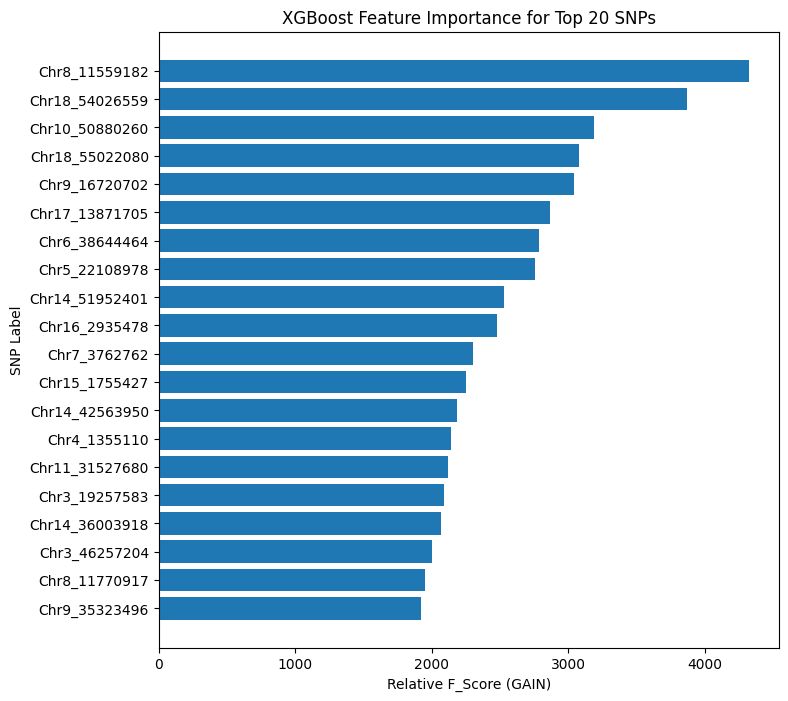

In [45]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, X_dupe, top_n=20)

In [46]:
explainer = shap.Explainer(best_xgbr_model)

In [47]:
shap_values = explainer(X_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

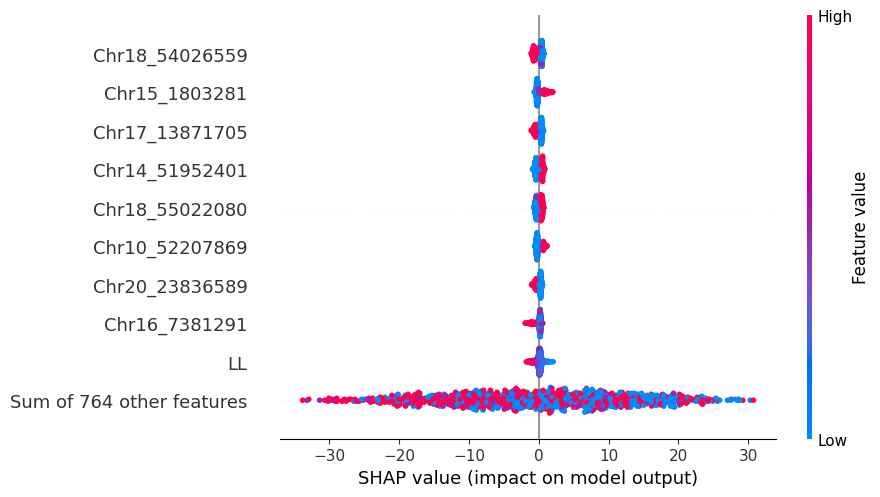

In [48]:
shap.plots.beeswarm(shap_values, show=False)

In [50]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [51]:
holdout_data = holdout_data.set_index('Line')

In [52]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [55]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [57]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [58]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [59]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 773 entries, Chr1_371931 to landrace
dtypes: float64(3), int64(770)
memory usage: 1.6+ MB


In [60]:
y_holdout.shape

(274, 1)

In [61]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -2.95
RMSE of Holdout: 23.32
Mean of Holdout: 355.60
This is 6.56% of the mean pheno data
0 355.712 367.16504
1 344.136 356.49963
2 351.481 367.09125
3 353.611 367.0575
4 390.342 359.30408
5 358.958 353.571


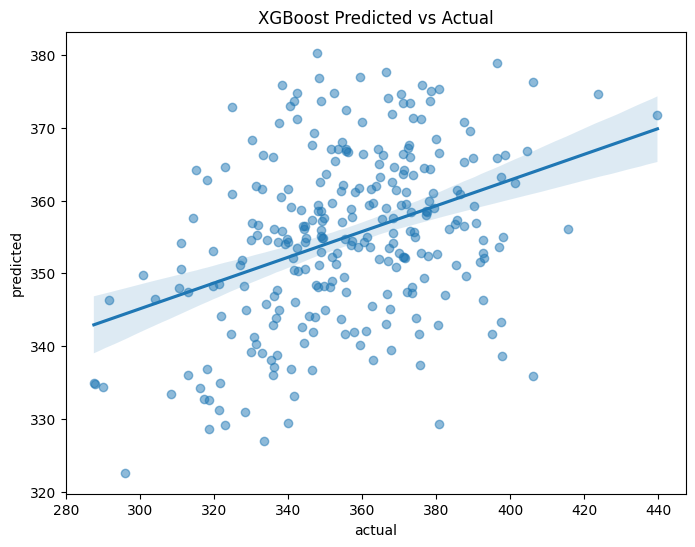

In [62]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [63]:
pickle.dump(best_xgbr_model, open("enet_allfeats_xgbr_prt.pickle.dat", "wb"))

In [64]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 12), ('max_features', 'sqrt'), ('max_samples', 0.5119626608534706), ('min_samples_leaf', 2), ('min_samples_split', 10), ('n_estimators', 461)])


In [70]:
best_rfr_model = eval_k_fold(best_rfreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.391170409893692
RMSE for dataset is:23.103567714384106& mean of this fold is 353.9678545454546
this is 6.527024253106936% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.0825179142837547
RMSE for dataset is:19.913679967812744& mean of this fold is 354.8670363636362
this is 5.611589110070785% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.1784150813369982
RMSE for dataset is:18.29647054538443& mean of this fold is 351.9230181818182
this is 5.198997962654352% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.3695176174377366
RMSE for dataset is:21.484843412968797& mean of this fold is 352.8248636363635
this is 6.089379073667553% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.928425502707075
RMSE for dat

R^2 Value of Holdout: -5.40
RMSE of Holdout: 22.82
Mean of Holdout: 355.60
This is 6.42% of the mean pheno data
0 355.712 364.39066376768295
1 344.136 354.4377683328724
2 351.481 361.4345727188897
3 353.611 361.3094385783285
4 390.342 361.64995415364336
5 358.958 355.0509139087184


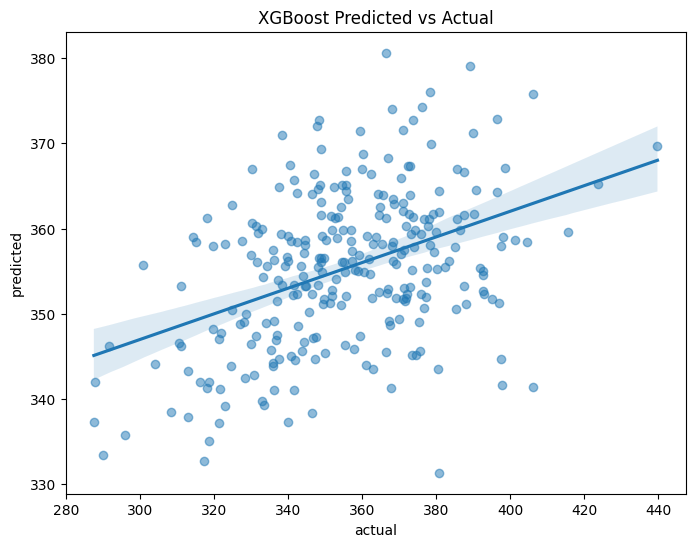

In [71]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [72]:
pickle.dump(best_rfr_model, open("enet_allfeats_rfr_prt.pickle.dat", "wb"))

In [73]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [74]:
best_svr_model = eval_k_fold(best_svreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.06286546166004792
RMSE for dataset is:23.068364864120813& mean of this fold is 349.65801818181825
this is 6.597407656793823% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.24490518914605164
RMSE for dataset is:22.40837052311812& mean of this fold is 354.7890454545454
this is 6.315970239275333% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.017614694445419077
RMSE for dataset is:22.975510911389133& mean of this fold is 352.9997727272727
this is 6.508647508150095% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.09091667676614423
RMSE for dataset is:21.605263272700164& mean of this fold is 355.27900909090914
this is 6.081210181255541% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.10943572749923847
RMSE 

R^2 Value of Holdout: -0.65
RMSE of Holdout: 28.63
Mean of Holdout: 355.60
This is 8.05% of the mean pheno data
0 355.712 397.133878862587
1 344.136 340.6553652949626
2 351.481 336.51393704897157
3 353.611 377.3064647654953
4 390.342 371.87292292950053
5 358.958 351.7520904530837


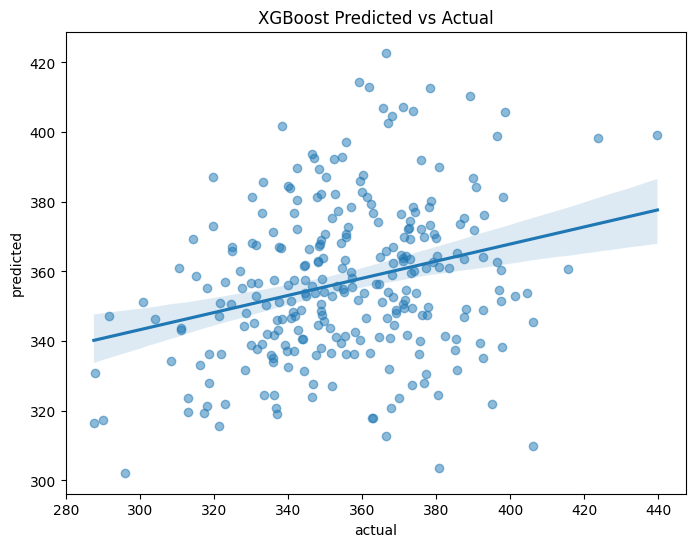

In [75]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

In [76]:
pickle.dump(best_svr_model, open("enet_allfeats_svr_prt.pickle.dat", "wb"))

## Only Location

In [77]:
snps_loc= fs_data.drop(['BBD', 'LL', 'LW', 'PLH', 'PRT'], axis=1)
snps_loc.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_45033350,Chr20_48338919,Chr20_48582557,Chr20_48641652,Chr20_50084112,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,0,0,0,2,0,1,0,0,0,1
s100,0,0,2,0,0,0,0,2,2,0,...,0,0,0,2,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,2,0,0,0,0,0,1,0,0,1
s101,2,0,2,0,0,2,2,2,0,2,...,0,2,0,0,0,0,0,1,0,1


In [78]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 769 entries, Chr1_371931 to landrace
dtypes: int64(769)
memory usage: 6.5+ MB


In [79]:
snps_loc_dupe= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
snps_loc_dupe.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_45033350,Chr20_48338919,Chr20_48582557,Chr20_48641652,Chr20_50084112,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,0,0,0,2,0,1,0,0,0,1
s100,0,0,2,0,0,0,0,2,2,0,...,0,0,0,2,0,0,1,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,2,0,...,2,0,0,0,0,0,1,0,0,1
s101,2,0,2,0,0,2,2,2,0,2,...,0,2,0,0,0,0,0,1,0,1


In [80]:
y_all = fs_data["PRT"].values

In [81]:
# Split training set into training and validation

In [82]:
X_train, X_test, y_train, y_test = train_test_split(snps_loc, y_all, test_size=0.1, random_state=42)

In [83]:
X_train = X_train.to_numpy()
#y_train = y_train.to_numpy()

In [84]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.9938049114186978), ('colsample_bytree', 1.0), ('gamma', 6.747793669303035e-06), ('learning_rate', 0.026323916496586372), ('max_delta_step', 20), ('max_depth', 50), ('min_child_weight', 2), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 1e-09), ('subsample', 0.14562938346671428)])


In [85]:
snps_loc = snps_loc.to_numpy()
#y_all = y_all.to_numpy()
best_xgbr_model = eval_k_fold(best_xgbreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.7408953043588473
RMSE for dataset is:21.158183007847548& mean of this fold is 357.6761545454545
this is 5.915458086585614% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.6874129108198519
RMSE for dataset is:18.243134163868184& mean of this fold is 357.67722727272724
this is 5.100446092968027% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.3422758355893536
RMSE for dataset is:20.264185772832835& mean of this fold is 353.97922727272726
this is 5.724682187980502% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.3026095822043575
RMSE for dataset is:21.597039518473164& mean of this fold is 351.3562636363637
this is 6.14676377046889% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.4229369774441747
RMSE for

In [86]:
pickle.dump(best_xgbr_model, open("enet_onlyloc_xgbr_prt.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top5_onlyloc_xgbr_bbd.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

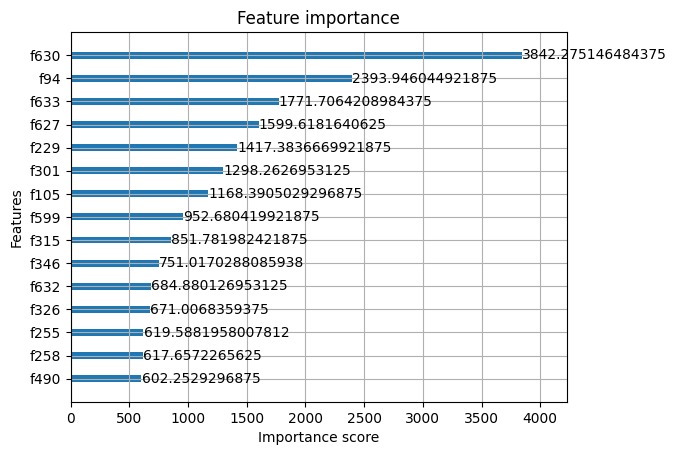

In [325]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

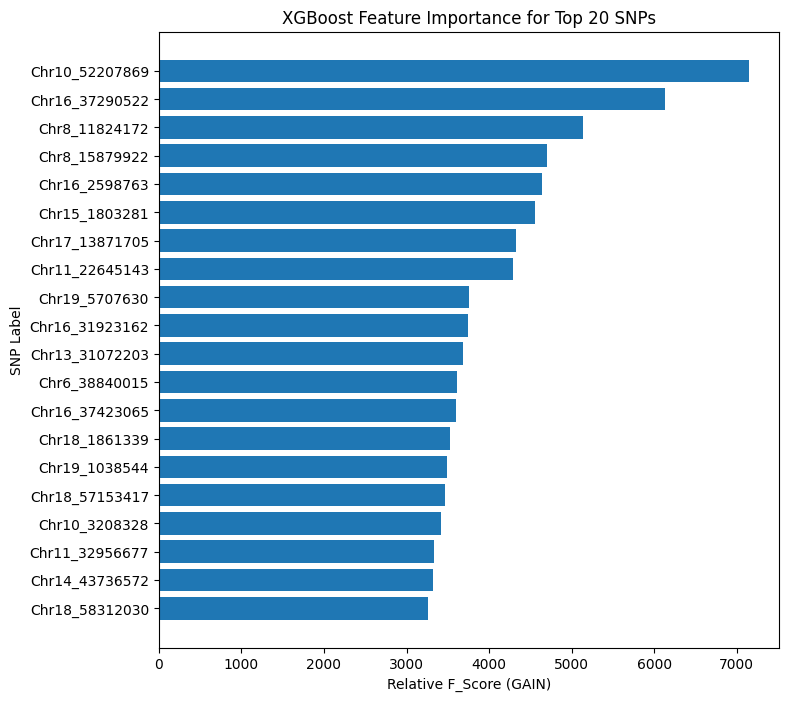

In [87]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, snps_loc_dupe, top_n=20)

In [88]:
explainer = shap.Explainer(best_xgbr_model)

In [89]:
shap_values = explainer(snps_loc_dupe, check_additivity=False)

<Axes: xlabel='SHAP value (impact on model output)'>

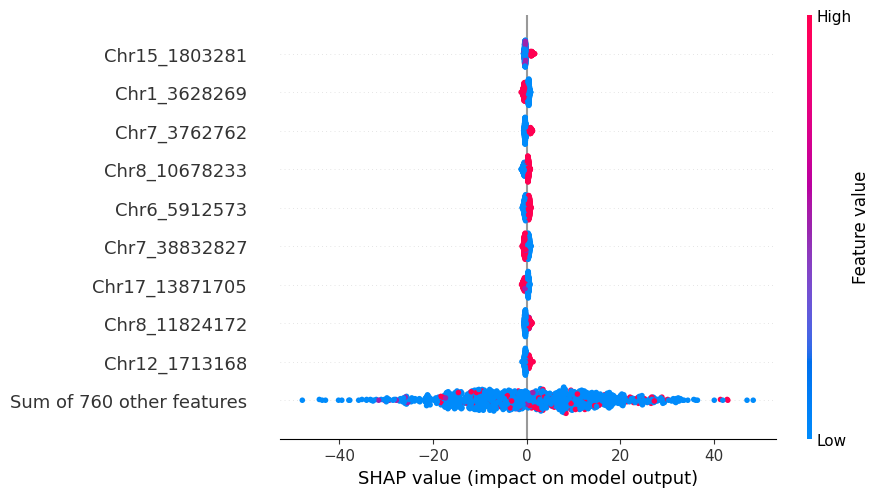

In [90]:
shap.plots.beeswarm(shap_values, show=False)

In [91]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [92]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [93]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [94]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [95]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [96]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 769 entries, Chr1_371931 to landrace
dtypes: int64(769)
memory usage: 1.6+ MB


In [97]:
X_holdout.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_45033350,Chr20_48338919,Chr20_48582557,Chr20_48641652,Chr20_50084112,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,2,0,2,0,0,2,2,2,0,2,...,0,2,0,0,0,1,0,0,0,1
s102,0,0,2,0,0,0,2,2,0,0,...,0,0,0,0,0,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,1,0,0,0,1
s112,0,2,2,2,2,0,0,2,2,1,...,2,0,0,0,2,1,0,0,0,1
s113,0,0,0,0,0,0,0,2,1,2,...,0,0,2,0,2,1,0,0,0,1


In [98]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -2.11
RMSE of Holdout: 23.71
Mean of Holdout: 355.60
This is 6.67% of the mean pheno data
0 355.712 372.31534
1 344.136 354.0323
2 351.481 366.0386
3 353.611 367.36734
4 390.342 358.91763
5 358.958 348.64273


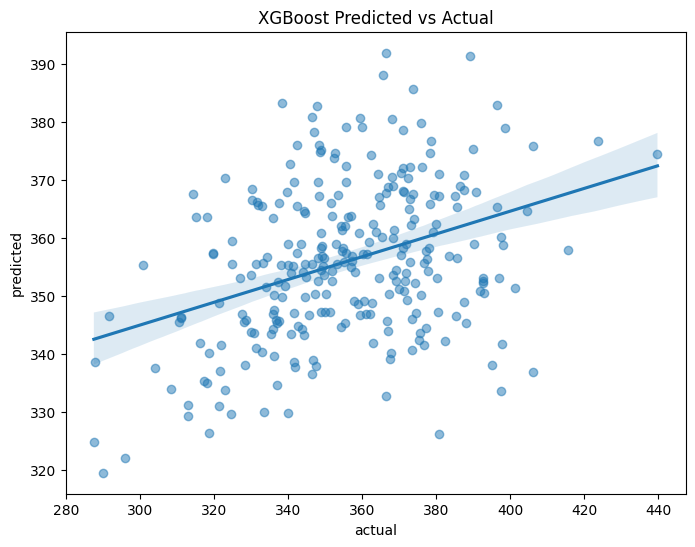

In [99]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [100]:
 # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 355.712 372.31534
1 344.136 354.0323
2 351.481 366.0386
3 353.611 367.36734
4 390.342 358.91763
5 358.958 348.64273


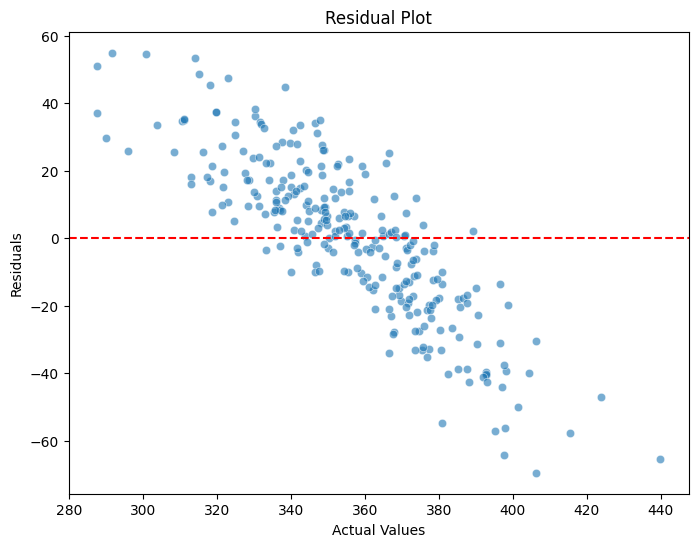

In [101]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [102]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 12), ('max_features', 'sqrt'), ('max_samples', 0.5119626608534706), ('min_samples_leaf', 2), ('min_samples_split', 10), ('n_estimators', 461)])


In [103]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.7692813022667053
RMSE for dataset is:20.59053482996716& mean of this fold is 357.08540000000005
this is 5.76627743110392% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.5321187076167453
RMSE for dataset is:18.061314110519756& mean of this fold is 354.6076909090909
this is 5.093322726367503% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.692134361505074
RMSE for dataset is:20.99783848051261& mean of this fold is 354.46199090909096
this is 5.923861801559969% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.76856889258492
RMSE for dataset is:20.792875825155633& mean of this fold is 355.3132636363636
this is 5.85198413714034% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.427119408632634
RMSE for datase

In [104]:
pickle.dump(best_rfr_model, open("enet_onlyloc_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -5.18
RMSE of Holdout: 22.96
Mean of Holdout: 355.60
This is 6.46% of the mean pheno data
0 355.712 363.7011553783257
1 344.136 356.38098700288316
2 351.481 363.73228180772367
3 353.611 359.93087970484294
4 390.342 360.48458053585983
5 358.958 354.54067162820326


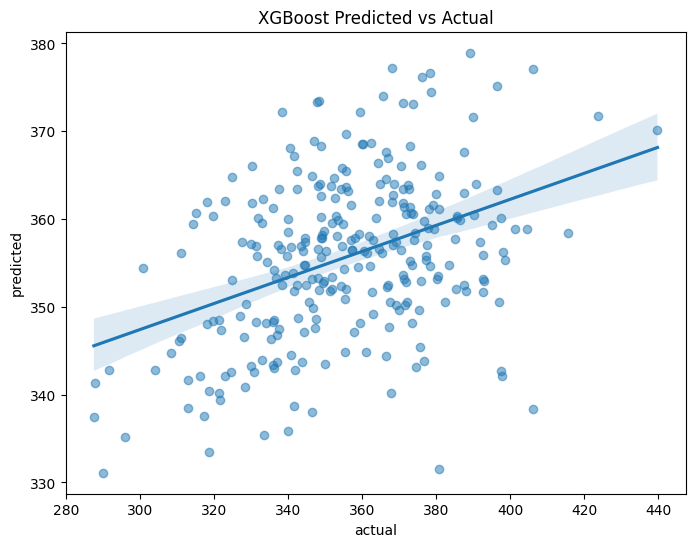

In [105]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [106]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 1.5), ('kernel', 'poly')])


In [107]:
best_svr_model = eval_k_fold(best_svreg, snps_loc, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.8945785012132337
RMSE for dataset is:18.07081440434601& mean of this fold is 356.24421818181816
this is 5.07259163294634% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.100684940038332
RMSE for dataset is:19.72591847554616& mean of this fold is 351.06596363636356
this is 5.618863837218465% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.4726039446375347
RMSE for dataset is:16.614031332267317& mean of this fold is 354.1450181818181
this is 4.691307368253779% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.795783591695588
RMSE for dataset is:19.737855671361885& mean of this fold is 353.5997272727272
this is 5.581977063047426% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.0428526362676775
RMSE for dat

In [108]:
pickle.dump(best_svr_model, open("enet_onlyloc_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -4.23
RMSE of Holdout: 23.17
Mean of Holdout: 355.60
This is 6.52% of the mean pheno data
0 355.712 363.9589019536117
1 344.136 357.7428890367311
2 351.481 361.7707341161771
3 353.611 362.8956014190424
4 390.342 359.6220694235425
5 358.958 356.3814421998292


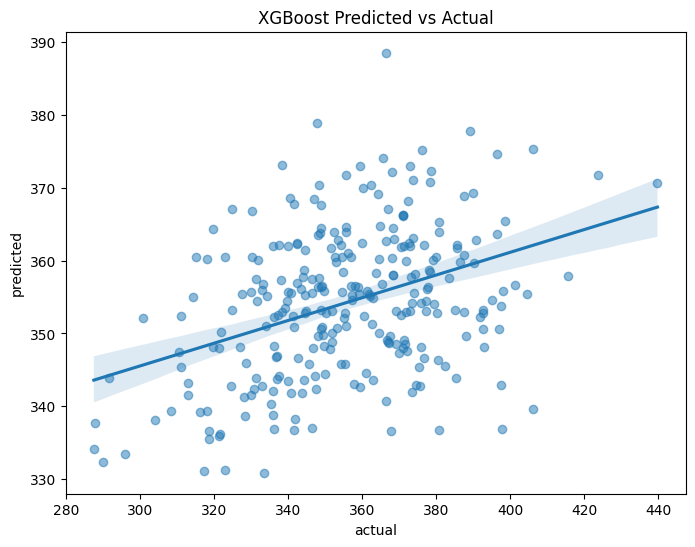

In [109]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

## Only snps

In [111]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 774 entries, Chr1_371931 to PRT
dtypes: float64(4), int64(770)
memory usage: 6.5+ MB


In [115]:
only_snps = fs_data.iloc[:, 0:764]
only_snps.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_39346951,Chr20_40346647,Chr20_40447898,Chr20_40962479,Chr20_41298997,Chr20_45033350,Chr20_48338919,Chr20_48582557,Chr20_48641652,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,0,1,0,0,2,0,0,0,2,0
s100,0,0,2,0,0,0,0,2,2,0,...,0,1,0,0,2,0,0,0,2,0
s1014,0,0,0,0,0,0,0,0,2,0,...,0,0,0,2,0,2,0,0,0,0
s1014,0,0,0,0,0,0,0,0,2,0,...,0,0,0,2,0,2,0,0,0,0
s101,2,0,2,0,0,2,2,2,0,2,...,0,1,1,0,2,0,2,0,0,0


In [117]:
only_snps_dupe = fs_data.iloc[:, 0:764]
only_snps.head()

,Chr1_371931,Chr1_988222,Chr1_1046903,Chr1_1051280,Chr1_1119786,Chr1_1956216,Chr1_2024622,Chr1_2079196,Chr1_3239090,Chr1_3628269,...,Chr20_39346951,Chr20_40346647,Chr20_40447898,Chr20_40962479,Chr20_41298997,Chr20_45033350,Chr20_48338919,Chr20_48582557,Chr20_48641652,Chr20_50084112
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,2,0,0,0,0,2,2,0,...,0,1,0,0,2,0,0,0,2,0
s100,0,0,2,0,0,0,0,2,2,0,...,0,1,0,0,2,0,0,0,2,0
s1014,0,0,0,0,0,0,0,0,2,0,...,0,0,0,2,0,2,0,0,0,0
s1014,0,0,0,0,0,0,0,0,2,0,...,0,0,0,2,0,2,0,0,0,0
s101,2,0,2,0,0,2,2,2,0,2,...,0,1,1,0,2,0,2,0,0,0


In [118]:
y_all = fs_data["PRT"]
y_all.head()

Line
s100     340.553
s100     358.104
s1014    366.116
s1014    326.667
s101     385.915
Name: PRT, dtype: float64

### Run models

In [119]:
X_train, X_test, y_train, y_test = train_test_split(only_snps, y_all, test_size=0.1, random_state=42)

In [120]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [121]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4825958805302847), ('colsample_bytree', 0.4397816411246381), ('gamma', 2.0910817152625037e-05), ('learning_rate', 0.05018601860941885), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 195), ('reg_alpha', 1.598943412668339e-08), ('reg_lambda', 1.1454274579395227e-07), ('subsample', 0.1536154650973617)])


In [122]:
only_snps = only_snps.to_numpy()
y_all = y_all.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5431225324163267
RMSE for dataset is:19.85830944745637& mean of this fold is 351.17709999999994
this is 5.654784849996305% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5339178532907467
RMSE for dataset is:19.20165663892976& mean of this fold is 354.1378909090908
this is 5.422084767500615% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.1025544003968508
RMSE for dataset is:22.057800054284026& mean of this fold is 356.5068909090909
this is 6.187201598834945% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.4083458601597736
RMSE for dataset is:20.451348729504204& mean of this fold is 355.55160000000006
this is 5.752005821237818% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.21854092859537033
RMSE for

In [123]:
pickle.dump(best_xgbr_model, open("enet_onlysnps_xgbr_prt.pickle.dat", "wb"))

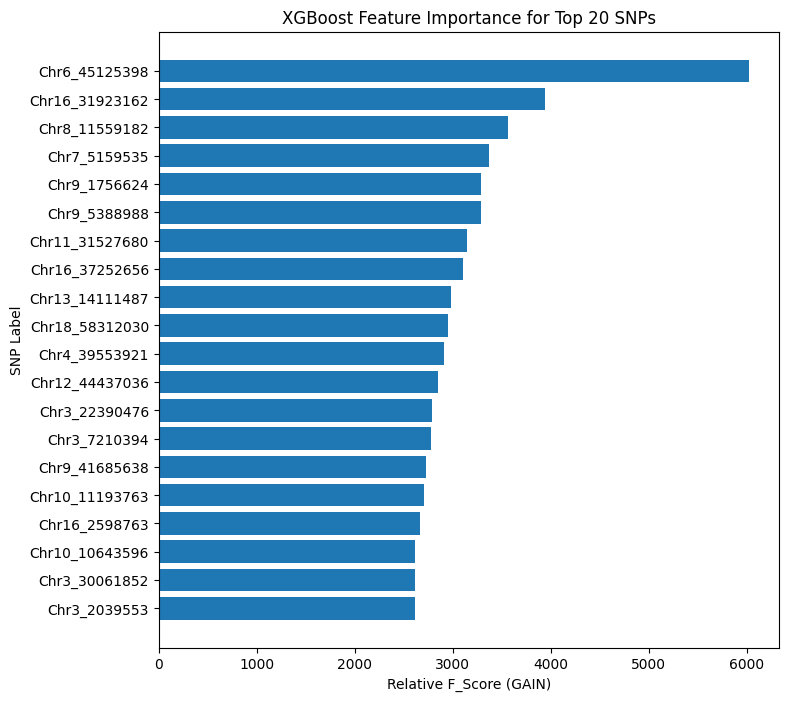

In [124]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, only_snps_dupe , top_n=20)

In [125]:
explainer = shap.Explainer(best_xgbr_model)

In [126]:
shap_values = explainer(only_snps_dupe)

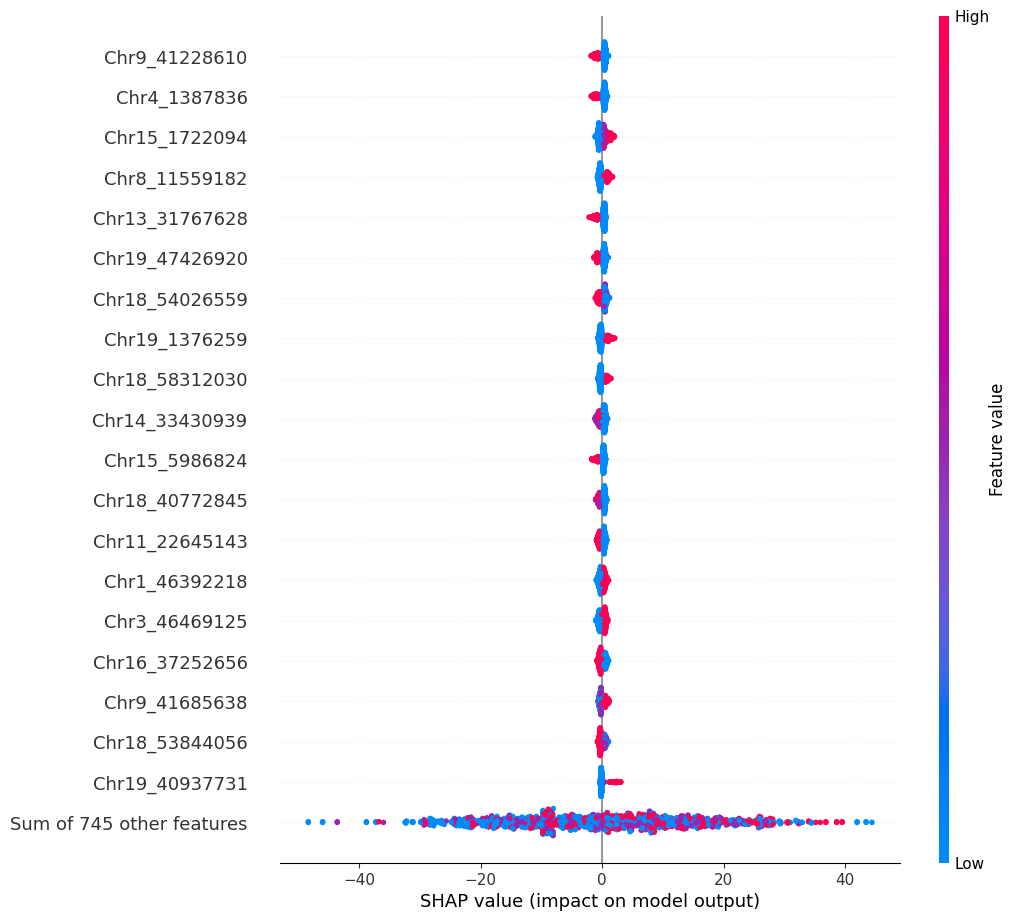

In [127]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])

In [128]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [129]:
holdout_data = holdout_data.set_index('Line')

In [130]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [131]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [132]:
# Ensure both trainjg and holdout datasets have the same columns
only_snps_dupe, X_holdout = only_snps_dupe.align(X_holdout, join='inner', axis=1)

In [133]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 764 entries, Chr1_371931 to Chr20_50084112
dtypes: int64(764)
memory usage: 1.6+ MB


In [134]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -1.43
RMSE of Holdout: 24.78
Mean of Holdout: 355.60
This is 6.97% of the mean pheno data
0 355.712 379.7553
1 344.136 363.7348
2 351.481 367.9795
3 353.611 372.25336
4 390.342 373.13678
5 358.958 347.92798


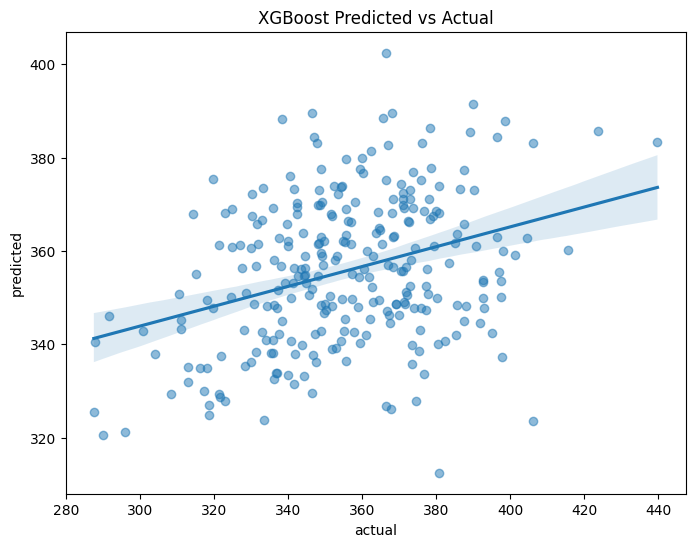

In [135]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [136]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 27), ('max_features', 'sqrt'), ('max_samples', 0.5014365841262769), ('min_samples_leaf', 2), ('min_samples_split', 6), ('n_estimators', 354)])


In [137]:
best_rfr_model = eval_k_fold(best_rfreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.500602207826884
RMSE for dataset is:20.27865745475708& mean of this fold is 354.94606363636365
this is 5.713165895405514% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.9249189114565595
RMSE for dataset is:20.063283596534788& mean of this fold is 353.3231636363636
this is 5.678451248439433% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.238690776604026
RMSE for dataset is:17.87938375838717& mean of this fold is 353.4146545454546
this is 5.0590385906274316% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.329545240072387
RMSE for dataset is:23.75482116974722& mean of this fold is 356.0142454545454
this is 6.672435576115212% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.2514067183212516
RMSE for data

In [138]:
pickle.dump(best_rfr_model, open("enet_onlysnps_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -4.21
RMSE of Holdout: 23.03
Mean of Holdout: 355.60
This is 6.48% of the mean pheno data
0 355.712 365.3876454903147
1 344.136 357.53612772692634
2 351.481 362.5688010817414
3 353.611 364.0435840328222
4 390.342 360.1056631491467
5 358.958 356.0918612645829


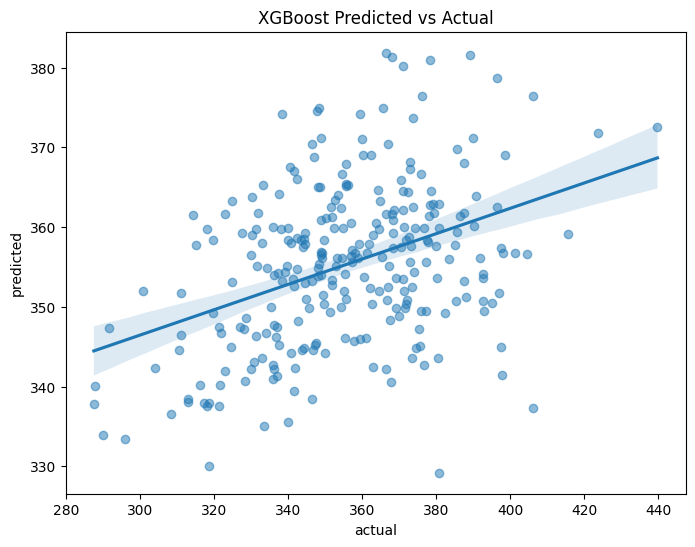

In [139]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [140]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 1.5), ('kernel', 'poly')])


In [141]:
best_svr_model = eval_k_fold(best_svreg, only_snps, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.4074785449879306
RMSE for dataset is:20.66358272899262& mean of this fold is 352.39399090909086
this is 5.863772726568236% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.8720374115595875
RMSE for dataset is:18.66849303897962& mean of this fold is 356.0390363636364
this is 5.243383767591363% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.1347159767451904
RMSE for dataset is:19.239479582697765& mean of this fold is 352.01220000000006
this is 5.465571813334242% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.9003320241939026
RMSE for dataset is:20.993106606149556& mean of this fold is 356.76276363636373
this is 5.884332319935475% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.7728293772211217
RMSE for

In [142]:
pickle.dump(best_svr_model, open("enet_onlysnps_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -4.08
RMSE of Holdout: 23.17
Mean of Holdout: 355.60
This is 6.52% of the mean pheno data
0 355.712 364.9295224294712
1 344.136 360.5550636522882
2 351.481 362.389163687322
3 353.611 366.2703879500416
4 390.342 361.6798202354226
5 358.958 359.1070434117047


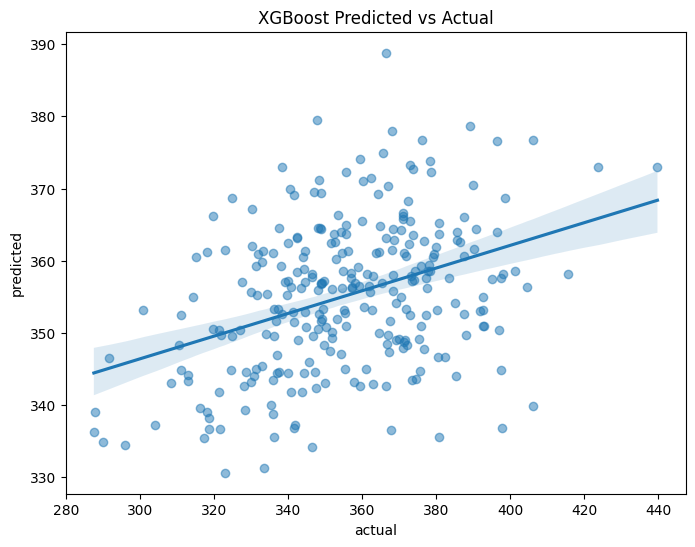

In [143]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)